In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns  # ← И ЭТУ (для красивой визуализации)

In [3]:
class PipeDataset(Dataset):
    def __init__(self, data_list, labels, scaler=None, fit_scaler=False):
        """
        data_list: список numpy массивов формы (length, 8)
        labels: список меток классов (int)
        """
        self.data_list = data_list
        self.labels = labels
        
        # Нормализация по всему датасету (важно!)
        if fit_scaler:
            # Объединяем все данные для расчета статистик
            all_data = np.vstack(data_list)  # (total_points, 8)
            self.scaler = StandardScaler().fit(all_data)
        else:
            self.scaler = scaler
            
        # Применяем нормализацию к каждому образцу
        self.data_list = [
            torch.FloatTensor(self.scaler.transform(sample)) 
            for sample in self.data_list
        ]
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        return self.data_list[idx], self.labels[idx]

def collate_fn(batch):
    """
    Формирует батч из данных переменной длины.
    Дополняет (pad) короткие последовательности нулями до самой длинной в батче.
    """
    data_list, labels = zip(*batch)
    
    # Находим максимальную длину в текущем батче
    max_len = max([d.shape[0] for d in data_list])
    
    # Создаем тензоры с паддингом
    padded_data = []
    lengths = []
    
    for data in data_list:
        length = data.shape[0]
        lengths.append(length)
        
        # Дополняем нулями до max_len: (length, 8) -> (max_len, 8)
        padding = torch.zeros(max_len - length, data.shape[1])
        padded = torch.cat([data, padding], dim=0)
        padded_data.append(padded)
    
    # Стек: (Batch, Max_Len, 8)
    data_batch = torch.stack(padded_data)
    labels_batch = torch.stack(labels)
    
    # Создаем маску для CNN (чтобы игнорировать паддинг при пулинге)
    # 1 = реальные данные, 0 = паддинг
    mask = torch.zeros(data_batch.shape[:2])
    for i, length in enumerate(lengths):
        mask[i, :length] = 1
    
    return data_batch, labels_batch, mask, torch.tensor(lengths)

In [4]:
class Pipe1DCNN(nn.Module):
    def __init__(self, input_channels=8, n_classes=3, dropout=0.3):
        super().__init__()
        
        self.features = nn.Sequential(
            # Блок 1
            nn.Conv1d(input_channels, 32, kernel_size=5, padding=2), # padding='same'
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),  # Уменьшаем длину в 2 раза
            
            # Блок 2
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),  # Уменьшаем длину в 2 раза
            
            # Блок 3
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            # АДАПТИВНЫЙ ПУЛИНГ - ключ к переменной длине!
            # Превращает (Batch, 128, Any_Length) -> (Batch, 128, 1)
            nn.AdaptiveAvgPool1d(1)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )
    
    def forward(self, x, mask=None):
        # Вход: (Batch, Length, 8) -> для Conv1d нужно (Batch, 8, Length)
        x = x.transpose(1, 2)
        x = self.features(x)  # (Batch, 128, 1)
        x = self.classifier(x)
        return x

In [5]:
class ImprovedPipeCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(8, 32, 9, padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU()
        )

        self.block1 = ResidualBlock(32)
        self.block2 = ResidualBlock(32)

        self.down = nn.Conv1d(32, 64, 3, stride=2, padding=1)

        self.block3 = ResidualBlock(64)
        self.block4 = ResidualBlock(64)

        self.attention = nn.Sequential(
            nn.Conv1d(64, 32, 1),
            nn.ReLU(),
            nn.Conv1d(32, 1, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        x = x.transpose(1, 2)

        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)

        x = self.down(x)

        x = self.block3(x)
        x = self.block4(x)

        w = self.attention(x)
        w = torch.softmax(w, dim=2)

        x = (x * w).sum(dim=2)

        return self.classifier(x)

In [6]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for data, labels, mask, lengths in loader:
        data, labels = data.to(device), labels.to(device)
        mask = mask.to(device)
        
        optimizer.zero_grad()
        outputs = model(data)  # mask можно использовать внутри модели при желании
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * data.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / total, 100. * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for data, labels, mask, lengths in loader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            
            loss = criterion(outputs, labels)
            total_loss += loss.item() * data.size(0)
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return (total_loss / total, 
            100. * correct / total, 
            all_preds, 
            all_labels)

In [7]:
import struct
from pathlib import Path
import numpy as np
from sklearn.model_selection import train_test_split
import os

def read_raw_file(filepath):
    """Читает .raw файл и возвращает данные в формате для нейросети"""
    path = Path(filepath)
    if not path.exists():
        raise FileNotFoundError(f"❌ Файл не найден: {path}")

    with open(path, 'rb') as f:
        data = f.read()

    if len(data) < 17:
        raise ValueError("⚠️ Файл слишком короткий")

    # Парсинг заголовка (Big-Endian)
    x = struct.unpack_from('>i', data, 0)[0]  # длина (например, 202)
    y = struct.unpack_from('>i', data, 4)[0]  # ширина (8)
    thicknom = struct.unpack_from('>d', data, 8)[0]
    defective = struct.unpack_from('>B', data, 16)[0]

    # Извлечение матрицы
    num_values = x * y
    matrix = struct.unpack(f'>{num_values}d', data[17:17+num_values*8])
    
    # Преобразование в numpy массив и ресейп в (length, 8)
    matrix_np = np.array(matrix, dtype=np.float32).reshape(x, y)
    
    return {
        'matrix': matrix_np,        # Форма: (202, 8)
        'defective': defective,     # 0 или 1
        'thicknom': thicknom,
        'filename': path.name
    }

def load_dataset_from_folder(folder_path, verbose=True):
    """Загружает все .raw файлы из папки"""
    folder = Path(folder_path)
    raw_files = list(folder.glob('*.raw'))
    
    if not raw_files:
        raise FileNotFoundError(f"❌ Не найдено .raw файлов в {folder_path}")
    
    if verbose:
        print(f"📁 Найдено файлов: {len(raw_files)}")
    
    data_list = []
    labels = []
    filenames = []
    
    good_count = 0
    bad_count = 0
    
    for file_path in raw_files:
        try:
            result = read_raw_file(file_path)
            data_list.append(result['matrix'])
            labels.append(result['defective'])
            filenames.append(result['filename'])
            
            if result['defective'] == 0:
                good_count += 1
            else:
                bad_count += 1
                
            if verbose and len(data_list) % 10 == 0:
                print(f"  Загружено: {len(data_list)}/{len(raw_files)}")
                
        except Exception as e:
            print(f"⚠️ Ошибка при чтении {file_path.name}: {e}")
            continue
    
    if verbose:
        print(f"\n✅ Загружено: {len(data_list)} файлов")
        print(f"   🟢 Годных (0): {good_count}")
        print(f"   🔴 Бракованных (1): {bad_count}")
        print(f"   📊 Размер матрицы: {data_list[0].shape}")
    
    return data_list, np.array(labels), filenames

def create_train_val_split(data_list, labels, test_size=0.2, random_state=42):
    """Разделяет данные на тренировочные и валидационные наборы"""
    
    X_train, X_val, y_train, y_val = train_test_split(
        data_list, 
        labels, 
        test_size=test_size, 
        random_state=random_state,
        stratify=labels  # Сохраняем баланс классов
    )
    
    print(f"\n📊 РАЗМЕРЫ ДАТАСЕТА:")
    print(f"   Train: {len(X_train)} образцов")
    print(f"   Val:   {len(X_val)} образцов")
    print(f"   Train классы: 0={sum(y_train==0)}, 1={sum(y_train==1)}")
    print(f"   Val классы:   0={sum(y_val==0)}, 1={sum(y_val==1)}")
    
    return X_train, X_val, y_train, y_val

# ============================================
# 🚀 ЗАПУСК ПОДГОТОВКИ ДАННЫХ
# ============================================

# Путь к папке с данными
DATASET_PATH = 'dataset'  # или полный путь 'D:/Универ/ВКР/Код/ПарсингДанных/DataTransform/scientificProject/dataset'

print("="*60)
print("🔄 ЗАГРУЗКА ДАННЫХ ИЗ .raw ФАЙЛОВ")
print("="*60)

# Загрузка всех файлов
data_list, labels, filenames = load_dataset_from_folder(DATASET_PATH)

# Разделение на train/val
X_train, X_val, y_train, y_val = create_train_val_split(
    data_list, 
    labels, 
    test_size=0.2,  # 20% на валидацию
    random_state=42
)

print("\n" + "="*60)
print("✅ ДАННЫЕ ГОТОВЫ ДЛЯ ОБУЧЕНИЯ!")
print("="*60)

# Теперь эти переменные можно использовать в вашем коде:
# X_train: список numpy массивов [(202, 8), (198, 8), ...]
# y_train: numpy массив меток [0, 1, 0, 1, ...]
# X_val, y_val: валидационные данные

🔄 ЗАГРУЗКА ДАННЫХ ИЗ .raw ФАЙЛОВ
📁 Найдено файлов: 3486
  Загружено: 10/3486
  Загружено: 20/3486
  Загружено: 30/3486
  Загружено: 40/3486
  Загружено: 50/3486
  Загружено: 60/3486
  Загружено: 70/3486
  Загружено: 80/3486
  Загружено: 90/3486
  Загружено: 100/3486
  Загружено: 110/3486
  Загружено: 120/3486
  Загружено: 130/3486
  Загружено: 140/3486
  Загружено: 150/3486
  Загружено: 160/3486
  Загружено: 170/3486
  Загружено: 180/3486
  Загружено: 190/3486
  Загружено: 200/3486
  Загружено: 210/3486
  Загружено: 220/3486
  Загружено: 230/3486
  Загружено: 240/3486
  Загружено: 250/3486
  Загружено: 260/3486
  Загружено: 270/3486
  Загружено: 280/3486
  Загружено: 290/3486
  Загружено: 300/3486
  Загружено: 310/3486
  Загружено: 320/3486
  Загружено: 330/3486
  Загружено: 340/3486
  Загружено: 350/3486
  Загружено: 360/3486
  Загружено: 370/3486
  Загружено: 380/3486
  Загружено: 390/3486
  Загружено: 400/3486
  Загружено: 410/3486
  Загружено: 420/3486
  Загружено: 430/3486
  Загру

In [8]:
import os
from datetime import datetime

# ============================================
# 📁 ФУНКЦИЯ СОЗДАНИЯ ПАПКИ ДЛЯ РЕЗУЛЬТАТОВ
# ============================================

def create_results_folder(epochs, batch_size, learning_rate, base_dir='results'):
    """Создаёт папку для сохранения результатов эксперимента"""
    # Формируем имя папки
    folder_name = f"1D_CNN_{epochs}epochs_{batch_size}batch_{learning_rate}lr"
    
    # Создаём полный путь
    results_dir = Path(base_dir) / folder_name
    
    # Создаём папку (и родительские, если нужно)
    results_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"\n📁 Папка результатов: {results_dir.absolute()}")
    
    return results_dir, folder_name

# ============================================
# === КОНФИГУРАЦИЯ ===
# ============================================

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.01
N_CLASSES = 2

# 📁 Создаём папку для результатов
results_dir, folder_prefix = create_results_folder(
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    learning_rate=LEARNING_RATE,
    base_dir='results'  # Можно изменить на путь по умолчанию
)

# ============================================
# 📊 ПОДГОТОВКА DATASET И DATALOADER
# ============================================

train_dataset = PipeDataset(X_train, y_train, fit_scaler=True)
val_dataset = PipeDataset(X_val, y_val, scaler=train_dataset.scaler)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn,
    num_workers=0
)

print(f"\n✅ DataLoader создан!")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")

# === МОДЕЛЬ ===
#model = Pipe1DCNN(input_channels=8, n_classes=N_CLASSES).to(DEVICE)
model = ImprovedPipeCNN(input_channels=8, n_classes=N_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
#optimizer = optim.Adamax(model.parameters(), lr=LEARNING_RATE,  betas=(0.9, 0.999), eps=1e-08,  weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.1)

print(f"\n🚀 Старт обучения на {DEVICE}")
print(f"📊 Размеров параметров: {sum(p.numel() for p in model.parameters()):,}")
print(f"📁 Результаты будут сохранены в: {results_dir}")

# === ХРАНИЛИЩЕ ИСТОРИИ ОБУЧЕНИЯ ===
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# === ЦИКЛ ОБУЧЕНИЯ ===
best_val_acc = 0
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion, DEVICE)
    
    # Сохраняем метрики
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    scheduler.step(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # 💾 Сохраняем модель в папку результатов
        torch.save(model.state_dict(), results_dir / 'best_pipe_cnn.pth')
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

# ============================================
# 📈 ФУНКЦИЯ ПОСТРОЕНИЯ ГРАФИКОВ (с путём)
# ============================================

def plot_training_history(history, results_dir, folder_prefix, save_name='training_plot.png'):
    """Строит графики потери и точности"""
    import matplotlib.pyplot as plt
    
    # Настройка шрифтов
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График потерь
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r--', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Эпоха', fontsize=11)
    axes[0].set_ylabel('Потеря (Loss)', fontsize=11)
    axes[0].set_title('📉 Динамика потери', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_axisbelow(True)
    
    # График точности
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r--', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Эпоха', fontsize=11)
    axes[1].set_ylabel('Точность (%)', fontsize=11)
    axes[1].set_title('📈 Динамика точности', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_axisbelow(True)
    
    plt.tight_layout()
    
    # 💾 Сохраняем с полным путём и префиксом
    save_path = results_dir / f"{folder_prefix}_{save_name}"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 График сохранён: {save_path}")
    
    return save_path

# ============================================
# === ФИНАЛЬНЫЙ ОТЧЕТ ===
# ============================================

print("\n" + "="*60)
print(f"✅ Лучшая точность валидации: {best_val_acc:.2f}%")
print(f"🏁 Обучение завершено после {EPOCHS} эпох")
print("="*60)

# 📊 Строим графики
print("\n📈 Строим графики обучения...")
plot_training_history(history, results_dir, folder_prefix, save_name='training_plot.png')

# 📋 Отчёт по классификации
try:
    from sklearn.metrics import classification_report, confusion_matrix
    import seaborn as sns
    
    print("\n📋 Classification Report:")
    print(classification_report(val_labels, val_preds, 
                             target_names=['Годный (0)', 'Брак (1)']))
    
    # 🗂️ Матрица ошибок
    cm = confusion_matrix(val_labels, val_preds)
    print("\n🗂️ Confusion Matrix:")
    print(cm)
    
    # Визуализация матрицы ошибок
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Годный', 'Брак'],
                yticklabels=['Годный', 'Брак'])
    plt.xlabel('Предсказано', fontsize=11)
    plt.ylabel('Фактически', fontsize=11)
    plt.title('🎯 Матрица ошибок', fontsize=13, fontweight='bold')
    plt.tight_layout()
    
    # 💾 Сохраняем с полным путём и префиксом
    cm_save_path = results_dir / f"{folder_prefix}_confusion_matrix.png"
    plt.savefig(cm_save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 Матрица ошибок сохранена: {cm_save_path}")
    
    # 📄 Сохраняем текстовый отчёт
    report_path = results_dir / f"{folder_prefix}_classification_report.txt"
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("="*60 + "\n")
        f.write(f"Отчёт о классификации\n")
        f.write(f"Дата: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*60 + "\n\n")
        f.write(f"Параметры модели:\n")
        f.write(f"  - Эпохи: {EPOCHS}\n")
        f.write(f"  - Batch Size: {BATCH_SIZE}\n")
        f.write(f"  - Learning Rate: {LEARNING_RATE}\n")
        f.write(f"  - Лучшая точность: {best_val_acc:.2f}%\n\n")
        f.write("Classification Report:\n")
        f.write(classification_report(val_labels, val_preds, 
                                     target_names=['Годный (0)', 'Брак (1)']))
        f.write("\nConfusion Matrix:\n")
        f.write(str(cm))
    
    print(f"💾 Текстовый отчёт сохранён: {report_path}")
    
except ImportError:
    print("\n⚠️ sklearn не установлен — пропускаем classification_report")
    print(f"Простая точность: {np.mean(np.array(val_preds) == np.array(val_labels)) * 100:.2f}%")

# ============================================
# 📄 СОХРАНЕНИЕ ПАРАМЕТРОВ ЭКСПЕРИМЕНТА
# ============================================

config_path = results_dir / f"{folder_prefix}_config.json"
import json

config = {
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'n_classes': N_CLASSES,
    'input_channels': 8,
    'best_val_acc': best_val_acc,
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'timestamp': datetime.now().isoformat(),
    'device': str(DEVICE)
}

with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"💾 Конфигурация сохранена: {config_path}")

# ============================================
# 📋 ИТОГОВАЯ ИНФОРМАЦИЯ
# ============================================

print("\n" + "="*60)
print("📁 ВСЕ ФАЙЛЫ СОХРАНЕНЫ В ПАПКУ:")
print(f"   {results_dir.absolute()}")
print("\n📄 Список сохранённых файлов:")
print(f"   1. {folder_prefix}_best_pipe_cnn.pth (веса модели)")
print(f"   2. {folder_prefix}_training_plot.png (графики)")
print(f"   3. {folder_prefix}_confusion_matrix.png (матрица ошибок)")
print(f"   4. {folder_prefix}_classification_report.txt (отчёт)")
print(f"   5. {folder_prefix}_config.json (параметры)")
print("="*60)

/home/strel/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0



📁 Папка результатов: /mnt/d/Универ/ВКР/Код/ПарсингДаных/DataTransform/scientificProject/results/1D_CNN_50epochs_32batch_0.01lr

✅ DataLoader создан!
   Train batches: 88
   Val batches:   22


TypeError: ImprovedPipeCNN.__init__() got an unexpected keyword argument 'input_channels'

🔥 GPU: CPU

📁 Папка результатов: /mnt/d/Универ/ВКР/Код/ПарсингДаных/DataTransform/scientificProject/results/CNN_LSTM_200epochs_32batch_0.001lr

✅ DataLoader создан!
   Train batches: 22
   Val batches:   6

🚀 Старт обучения на cpu
📊 Размеров параметров: 1,971,810
📁 Результаты будут сохранены в: results/CNN_LSTM_200epochs_32batch_0.001lr


/tmp/ipykernel_46448/2788451212.py:375: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/home/strel/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(
/home/strel/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_46448/2788451212.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # 🔥
/home/strel/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or

  ⭐ Новая лучшая модель! Acc: 61.46%
Epoch 01 | Train Loss: 0.5239 Acc: 71.05% | Val Loss: 1.8341 Acc: 61.46%
  ⭐ Новая лучшая модель! Acc: 79.80%
Epoch 02 | Train Loss: 0.2814 Acc: 90.24% | Val Loss: 0.5466 Acc: 79.80%
  ⭐ Новая лучшая модель! Acc: 83.81%
Epoch 03 | Train Loss: 0.2395 Acc: 91.50% | Val Loss: 0.3807 Acc: 83.81%
  ⭐ Новая лучшая модель! Acc: 85.67%
Epoch 04 | Train Loss: 0.2090 Acc: 91.57% | Val Loss: 0.3533 Acc: 85.67%
Epoch 05 | Train Loss: 0.1935 Acc: 92.50% | Val Loss: 0.4150 Acc: 83.38%
  ⭐ Новая лучшая модель! Acc: 87.39%
Epoch 06 | Train Loss: 0.1841 Acc: 92.68% | Val Loss: 0.3411 Acc: 87.39%
  ⭐ Новая лучшая модель! Acc: 87.82%
Epoch 07 | Train Loss: 0.1794 Acc: 93.11% | Val Loss: 0.3741 Acc: 87.82%
Epoch 08 | Train Loss: 0.1768 Acc: 93.26% | Val Loss: 0.3609 Acc: 86.25%
Epoch 09 | Train Loss: 0.1662 Acc: 93.90% | Val Loss: 0.3758 Acc: 86.96%
  ⭐ Новая лучшая модель! Acc: 90.40%
Epoch 10 | Train Loss: 0.1744 Acc: 93.33% | Val Loss: 0.2480 Acc: 90.40%
Epoch 11 | 

/tmp/ipykernel_46448/2788451212.py:165: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_46448/2788451212.py:165: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_46448/2788451212.py:167: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipykernel_46448/2788451212.py:167: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/home/strel/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/strel/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.p

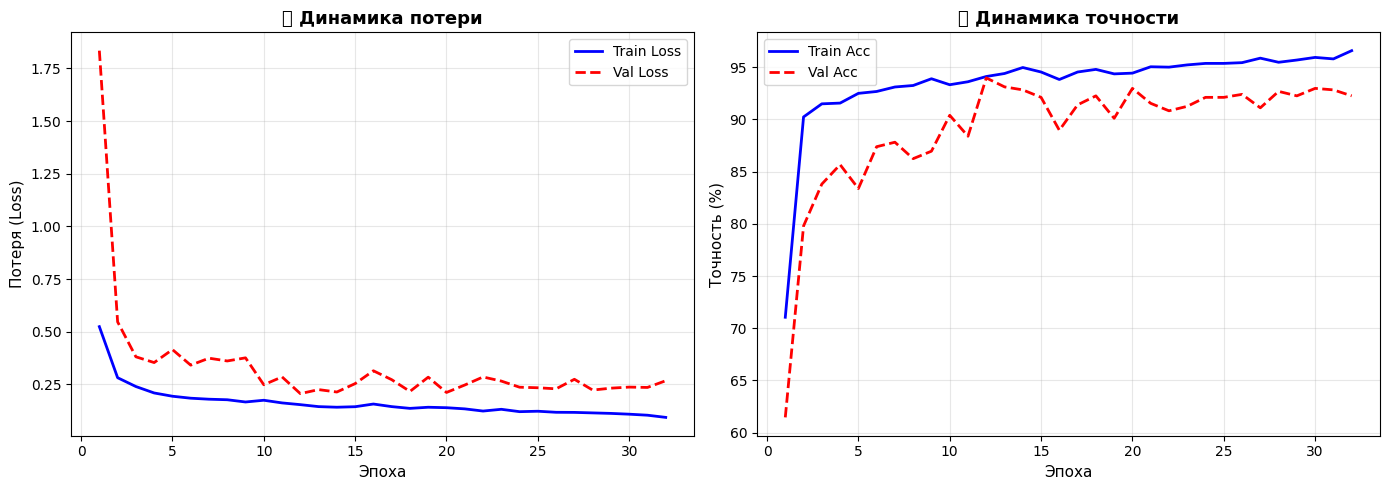

💾 График сохранён: results/CNN_LSTM_200epochs_32batch_0.001lr/CNN_LSTM_200epochs_32batch_0.001lr_training_plot.png

📋 Classification Report:
              precision    recall  f1-score   support

  Годный (0)       0.89      0.99      0.94       427
    Брак (1)       0.99      0.81      0.89       271

    accuracy                           0.92       698
   macro avg       0.94      0.90      0.92       698
weighted avg       0.93      0.92      0.92       698


🗂️ Confusion Matrix:
[[424   3]
 [ 51 220]]


/tmp/ipykernel_46448/2788451212.py:440: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_46448/2788451212.py:443: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig(cm_save_path, dpi=300, bbox_inches='tight')
/home/strel/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


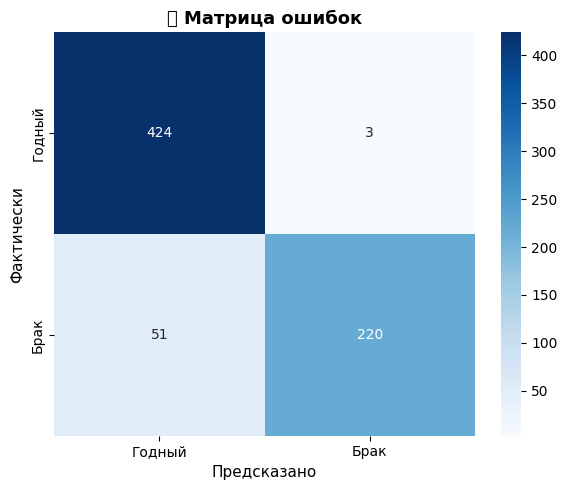

💾 Матрица ошибок сохранена: results/CNN_LSTM_200epochs_32batch_0.001lr/CNN_LSTM_200epochs_32batch_0.001lr_confusion_matrix.png
💾 Текстовый отчёт сохранён: results/CNN_LSTM_200epochs_32batch_0.001lr/CNN_LSTM_200epochs_32batch_0.001lr_classification_report.txt
💾 Конфигурация сохранена: results/CNN_LSTM_200epochs_32batch_0.001lr/CNN_LSTM_200epochs_32batch_0.001lr_config.json

📁 ВСЕ ФАЙЛЫ СОХРАНЕНЫ В ПАПКУ:
   /mnt/d/Универ/ВКР/Код/ПарсингДаных/DataTransform/scientificProject/results/CNN_LSTM_200epochs_32batch_0.001lr

📄 Список сохранённых файлов:
   1. CNN_LSTM_200epochs_32batch_0.001lr_best_pipe_cnn_lstm.pth (веса модели)
   2. CNN_LSTM_200epochs_32batch_0.001lr_training_plot.png (графики)
   3. CNN_LSTM_200epochs_32batch_0.001lr_confusion_matrix.png (матрица ошибок)
   4. CNN_LSTM_200epochs_32batch_0.001lr_classification_report.txt (отчёт)
   5. CNN_LSTM_200epochs_32batch_0.001lr_config.json (параметры)


In [10]:
import os
from datetime import datetime
from pathlib import Path
import torch


# 🚀 Включаем оптимизации CUDA
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True

# Если фиксированные размеры — ускорит сильно
torch.backends.cudnn.deterministic = False
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import json
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# ============================================
# 📁 ФУНКЦИЯ СОЗДАНИЯ ПАПКИ ДЛЯ РЕЗУЛЬТАТОВ
# ============================================



def create_results_folder(epochs, batch_size, learning_rate, model_type='CNN_LSTM', base_dir='results'):
    """Создаёт папку для сохранения результатов эксперимента"""
    folder_name = f"{model_type}_{epochs}epochs_{batch_size}batch_{learning_rate}lr"
    results_dir = Path(base_dir) / folder_name
    results_dir.mkdir(parents=True, exist_ok=True)
    print(f"\n📁 Папка результатов: {results_dir.absolute()}")
    return results_dir, folder_name

# ============================================
# 📊 PIPE DATASET (с нормализацией)
# ============================================

class PipeDataset(Dataset):
    def __init__(self, data_list, labels, scaler=None, fit_scaler=False):
        if fit_scaler:
            all_data = np.vstack(data_list)
            from sklearn.preprocessing import StandardScaler
            self.scaler = StandardScaler().fit(all_data)
        else:
            self.scaler = scaler
        
        self.data_list = [torch.FloatTensor(self.scaler.transform(sample)) 
                         for sample in data_list]
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        return self.data_list[idx], self.labels[idx]

def collate_fn(batch):
    """Формирует батч с padding для переменной длины"""
    data_list, labels = zip(*batch)
    max_len = max([d.shape[0] for d in data_list])
    
    padded_data = []
    lengths = []
    
    for data in data_list:
        length = data.shape[0]
        lengths.append(length)
        padding = torch.zeros(max_len - length, data.shape[1])
        padded = torch.cat([data, padding], dim=0)
        padded_data.append(padded)
    
    return torch.stack(padded_data), torch.stack(labels), torch.tensor(lengths)

# ============================================
# 📈 ФУНКЦИИ ОБУЧЕНИЯ И ОЦЕНКИ
# ============================================

def train_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for data, labels, lengths in loader:
        data = data.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        lengths = lengths.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():  # 🔥
            outputs = model(data, lengths)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * data.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / total, 100. * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for data, labels, lengths in loader:
            data = data.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():
                outputs = model(data, lengths)
                loss = criterion(outputs, labels)

            total_loss += loss.item() * data.size(0)
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, 100. * correct / total, all_preds, all_labels

# ============================================
# 📈 ФУНКЦИЯ ПОСТРОЕНИЯ ГРАФИКОВ
# ============================================

def plot_training_history(history, results_dir, folder_prefix, save_name='training_plot.png'):
    import matplotlib.pyplot as plt
    
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График потерь
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r--', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Эпоха', fontsize=11)
    axes[0].set_ylabel('Потеря (Loss)', fontsize=11)
    axes[0].set_title('📉 Динамика потери', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_axisbelow(True)
    
    # График точности
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r--', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Эпоха', fontsize=11)
    axes[1].set_ylabel('Точность (%)', fontsize=11)
    axes[1].set_title('📈 Динамика точности', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_axisbelow(True)
    
    plt.tight_layout()
    save_path = results_dir / f"{folder_prefix}_{save_name}"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 График сохранён: {save_path}")

# ============================================
# === ХРАНИЛИЩЕ ИСТОРИИ ===
# ============================================

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}




# ============================================
#  МОДЕЛЬ CNN + LSTM (HYBRID)
# ============================================

class PipeCNNLSTM(nn.Module):
    def __init__(self, input_channels=8, n_classes=2, 
                 cnn_filters=[32, 64, 128], 
                 lstm_hidden=128, 
                 lstm_layers=4,
                 dropout=0.3):
        super().__init__()
        
        # === CNN БЛОК (извлекает локальные признаки) ===
        cnn_layers = []
        in_channels = input_channels
        
        for filters in cnn_filters:
            cnn_layers.extend([
                nn.Conv1d(in_channels, filters, kernel_size=5, padding=2),
                nn.BatchNorm1d(filters),
                nn.ReLU(),
                nn.MaxPool1d(2),  # Уменьшаем длину в 2 раза
                nn.Dropout(dropout)
            ])
            in_channels = filters
        
        self.cnn = nn.Sequential(*cnn_layers)
        
        # === LSTM БЛОК (анализирует последовательность признаков) ===
        self.lstm = nn.LSTM(
            input_size=cnn_filters[-1],
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,  # Двусторонний LSTM
            dropout=dropout if lstm_layers > 1 else 0
        )
        
        # === Классификатор ===
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 64),  # *2 для bidirectional
            #nn.ReLU(),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )
    
    def forward(self, x, lengths=None):
        # x: (B, L, C)
    
        # === CNN ===
        x = x.transpose(1, 2)
        x = self.cnn(x)
        x = x.transpose(1, 2)
    
        # === корректировка длин ===
        if lengths is not None:
            lengths = lengths.clone()
    
            for _ in range(2):  # число MaxPool
                lengths = (lengths + 1) // 2
    
            lengths = torch.clamp(lengths, max=x.shape[1])
    
        # === PACK ===
        if lengths is not None:
            lengths_cpu = lengths.cpu()
    
            packed = pack_padded_sequence(
                x,
                lengths_cpu,
                batch_first=True,
                enforce_sorted=False
            )
    
            packed_out, (h_n, _) = self.lstm(packed)
    
            lstm_out, _ = pad_packed_sequence(
                packed_out,
                batch_first=True
            )
        else:
            lstm_out, (h_n, _) = self.lstm(x)
    
        # === ВЫХОД ===
        if self.lstm.bidirectional:
            h_cat = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            h_cat = h_n[-1]
    
        return self.classifier(h_cat)


# ============================================
# === КОНФИГУРАЦИЯ ===
# ============================================

#DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print("🔥 GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

BATCH_SIZE = 32  # Уменьшили для LSTM (требует больше памяти)
EPOCHS = 200     # Увеличили (LSTM обучается медленнее)
LEARNING_RATE = 0.001  # Оптимально для Adam + LSTM
N_CLASSES = 2
MODEL_TYPE = 'CNN_LSTM'

# 📁 Создаём папку для результатов
results_dir, folder_prefix = create_results_folder(
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    learning_rate=LEARNING_RATE,
    model_type=MODEL_TYPE,
    base_dir='results'
)

# ============================================
# 📊 ПОДГОТОВКА DATASET И DATALOADER
# ============================================

train_dataset = PipeDataset(X_train, y_train, fit_scaler=True)
val_dataset = PipeDataset(X_val, y_val, scaler=train_dataset.scaler)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,              # ⬅️ увеличили
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4,               # ⬅️ ВАЖНО
    pin_memory=True,             # ⬅️ ВАЖНО
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print(f"\n✅ DataLoader создан!")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")

# ============================================
# === МОДЕЛЬ ===
# ============================================

model = PipeCNNLSTM(
    input_channels=8, 
    n_classes=N_CLASSES,
    cnn_filters=[32, 64, 512, 128],
    lstm_hidden=128,
    lstm_layers=4,
    dropout=0.2  # Увеличенный dropout для борьбы с переобучением
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

# Class weights для несбалансированных данных
# from sklearn.utils.class_weight import compute_class_weight
# class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights).to(DEVICE))

optimizer = optim.Adamax(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max', 
    patience=10,    # Увеличили patience для LSTM
    factor=0.5,
    min_lr=1e-6
)

print(f"\n🚀 Старт обучения на {DEVICE}")
print(f"📊 Размеров параметров: {sum(p.numel() for p in model.parameters()):,}")
print(f"📁 Результаты будут сохранены в: {results_dir}")



# ============================================
# === ЦИКЛ ОБУЧЕНИЯ ===
# ============================================

best_val_acc = 0
patience_counter = 0
early_stop_patience = 20  # Early stopping
scaler = torch.cuda.amp.GradScaler()

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE, scaler)
    val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion, DEVICE)
    
    # Сохраняем метрики
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    scheduler.step(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), results_dir / 'best_pipe_cnn_lstm.pth')
        print(f"  ⭐ Новая лучшая модель! Acc: {val_acc:.2f}%")
    else:
        patience_counter += 1
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")
    
    # Early Stopping
    if patience_counter >= early_stop_patience:
        print(f"\n🛑 Early stopping на эпохе {epoch+1} (нет улучшений {early_stop_patience} эпох)")
        break

# ============================================
# === ФИНАЛЬНЫЙ ОТЧЕТ ===
# ============================================

print("\n" + "="*60)
print(f"✅ Лучшая точность валидации: {best_val_acc:.2f}%")
print(f"🏁 Обучение завершено после {len(history['train_acc'])} эпох")
print("="*60)

# 📊 Строим графики
print("\n📈 Строим графики обучения...")
plot_training_history(history, results_dir, folder_prefix, save_name='training_plot.png')

# 📋 Отчёт по классификации
try:
    from sklearn.metrics import classification_report, confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    print("\n📋 Classification Report:")
    print(classification_report(val_labels, val_preds, 
                             target_names=['Годный (0)', 'Брак (1)']))
    
    cm = confusion_matrix(val_labels, val_preds)
    print("\n🗂️ Confusion Matrix:")
    print(cm)
    
    # Визуализация матрицы ошибок
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Годный', 'Брак'],
                yticklabels=['Годный', 'Брак'])
    plt.xlabel('Предсказано', fontsize=11)
    plt.ylabel('Фактически', fontsize=11)
    plt.title('🎯 Матрица ошибок', fontsize=13, fontweight='bold')
    plt.tight_layout()
    
    cm_save_path = results_dir / f"{folder_prefix}_confusion_matrix.png"
    plt.savefig(cm_save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 Матрица ошибок сохранена: {cm_save_path}")
    
    # Текстовый отчёт
    report_path = results_dir / f"{folder_prefix}_classification_report.txt"
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("="*60 + "\n")
        f.write(f"Отчёт о классификации CNN+LSTM\n")
        f.write(f"Дата: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*60 + "\n\n")
        f.write(f"Параметры модели:\n")
        f.write(f"  - Модель: {MODEL_TYPE}\n")
        f.write(f"  - Эпохи: {EPOCHS}\n")
        f.write(f"  - Batch Size: {BATCH_SIZE}\n")
        f.write(f"  - Learning Rate: {LEARNING_RATE}\n")
        f.write(f"  - LSTM Hidden: 128\n")
        f.write(f"  - LSTM Layers: 2\n")
        f.write(f"  - Лучшая точность: {best_val_acc:.2f}%\n\n")
        f.write("Classification Report:\n")
        f.write(classification_report(val_labels, val_preds, 
                                     target_names=['Годный (0)', 'Брак (1)']))
        f.write("\nConfusion Matrix:\n")
        f.write(str(cm))
    
    print(f"💾 Текстовый отчёт сохранён: {report_path}")
    
except ImportError:
    print("\n⚠️ sklearn не установлен")
    print(f"Простая точность: {np.mean(np.array(val_preds) == np.array(val_labels)) * 100:.2f}%")

# ============================================
# 📄 СОХРАНЕНИЕ КОНФИГУРАЦИИ
# ============================================

config_path = results_dir / f"{folder_prefix}_config.json"

config = {
    'model_type': MODEL_TYPE,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'n_classes': N_CLASSES,
    'input_channels': 8,
    'cnn_filters': [32, 64, 128],
    'lstm_hidden': 128,
    'lstm_layers': 2,
    'dropout': 0.4,
    'best_val_acc': best_val_acc,
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'actual_epochs': len(history['train_acc']),
    'timestamp': datetime.now().isoformat(),
    'device': str(DEVICE)
}

with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"💾 Конфигурация сохранена: {config_path}")

# ============================================
# 📋 ИТОГОВАЯ ИНФОРМАЦИЯ
# ============================================

print("\n" + "="*60)
print("📁 ВСЕ ФАЙЛЫ СОХРАНЕНЫ В ПАПКУ:")
print(f"   {results_dir.absolute()}")
print("\n📄 Список сохранённых файлов:")
print(f"   1. {folder_prefix}_best_pipe_cnn_lstm.pth (веса модели)")
print(f"   2. {folder_prefix}_training_plot.png (графики)")
print(f"   3. {folder_prefix}_confusion_matrix.png (матрица ошибок)")
print(f"   4. {folder_prefix}_classification_report.txt (отчёт)")
print(f"   5. {folder_prefix}_config.json (параметры)")
print("="*60)

Transformer

🔥 GPU: CPU

📁 Папка результатов: /mnt/d/Универ/ВКР/Код/ПарсингДаных/DataTransform/scientificProject/results/Transformer_150epochs_64batch_0.0005lr

✅ DataLoader создан!
   Train batches: 44
   Val batches:   11

🚀 Старт обучения Transformer на cpu
📊 Размеров параметров: 539,715
📁 Результаты будут сохранены в: results/Transformer_150epochs_64batch_0.0005lr
🎯 Mixed Precision: Enabled


/tmp/ipykernel_46448/1872842308.py:120: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(
/tmp/ipykernel_46448/1872842308.py:356: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/home/strel/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(
/home/strel/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_46448/1872842308.py:167: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.am

  ⭐ Новая лучшая модель! Acc: 38.54%
Epoch 01 | Train Loss: 0.8060 Acc: 44.44% | Val Loss: 0.7278 Acc: 38.54%
  ⭐ Новая лучшая модель! Acc: 61.75%
Epoch 02 | Train Loss: 0.7981 Acc: 43.83% | Val Loss: 0.6731 Acc: 61.75%
  ⭐ Новая лучшая модель! Acc: 62.75%
Epoch 03 | Train Loss: 0.7283 Acc: 51.43% | Val Loss: 0.6403 Acc: 62.75%
Epoch 04 | Train Loss: 0.6799 Acc: 58.97% | Val Loss: 0.6905 Acc: 62.03%
Epoch 05 | Train Loss: 0.6687 Acc: 60.40% | Val Loss: 0.7094 Acc: 62.18%
Epoch 06 | Train Loss: 0.6637 Acc: 60.47% | Val Loss: 0.7177 Acc: 62.32%
Epoch 07 | Train Loss: 0.6479 Acc: 63.74% | Val Loss: 0.7389 Acc: 62.32%
Epoch 08 | Train Loss: 0.6413 Acc: 63.09% | Val Loss: 0.7134 Acc: 62.46%
Epoch 09 | Train Loss: 0.6412 Acc: 63.70% | Val Loss: 0.7064 Acc: 62.61%
  ⭐ Новая лучшая модель! Acc: 62.89%
Epoch 10 | Train Loss: 0.6391 Acc: 63.20% | Val Loss: 0.6978 Acc: 62.89%
Epoch 11 | Train Loss: 0.6370 Acc: 64.10% | Val Loss: 0.7255 Acc: 62.89%
Epoch 12 | Train Loss: 0.6319 Acc: 64.31% | Val L

/tmp/ipykernel_46448/1872842308.py:243: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_46448/1872842308.py:243: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_46448/1872842308.py:245: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipykernel_46448/1872842308.py:245: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/home/strel/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/strel/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.p

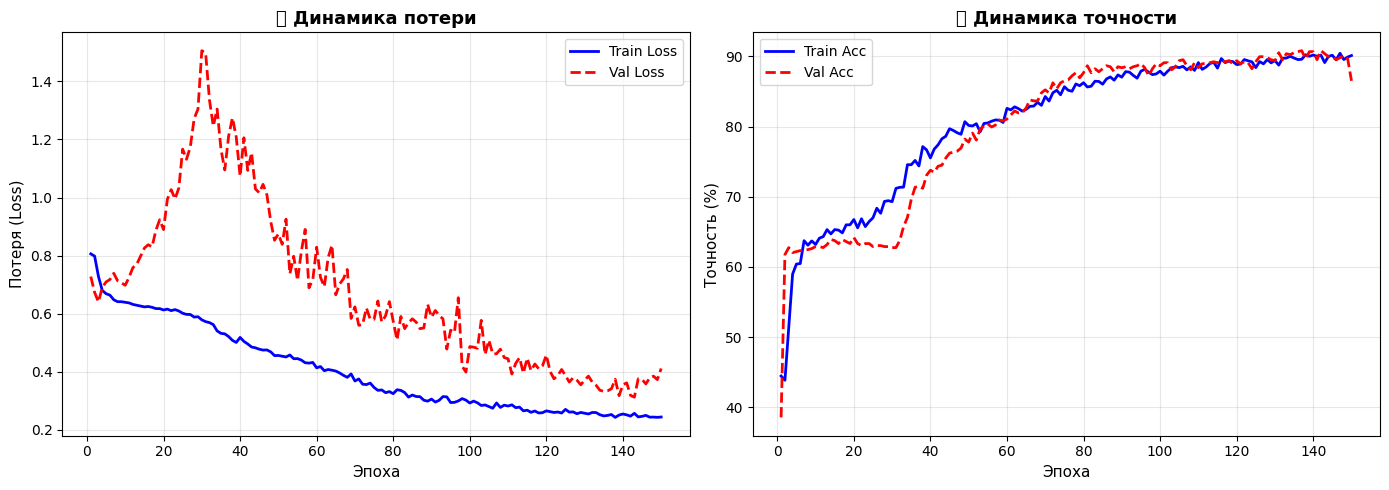

💾 График сохранён: results/Transformer_150epochs_64batch_0.0005lr/Transformer_150epochs_64batch_0.0005lr_training_plot.png

📋 Classification Report:
              precision    recall  f1-score   support

  Годный (0)       0.92      0.85      0.89       427
    Брак (1)       0.79      0.88      0.84       271

    accuracy                           0.87       698
   macro avg       0.86      0.87      0.86       698
weighted avg       0.87      0.87      0.87       698


🗂️ Confusion Matrix:
[[365  62]
 [ 32 239]]


/tmp/ipykernel_46448/1872842308.py:443: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_46448/1872842308.py:446: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig(cm_save_path, dpi=300, bbox_inches='tight')
/home/strel/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


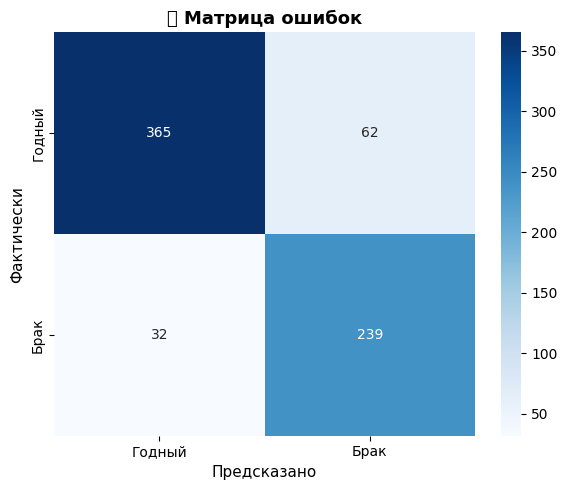

💾 Матрица ошибок сохранена: results/Transformer_150epochs_64batch_0.0005lr/Transformer_150epochs_64batch_0.0005lr_confusion_matrix.png
💾 Текстовый отчёт сохранён: results/Transformer_150epochs_64batch_0.0005lr/Transformer_150epochs_64batch_0.0005lr_classification_report.txt
💾 Конфигурация сохранена: results/Transformer_150epochs_64batch_0.0005lr/Transformer_150epochs_64batch_0.0005lr_config.json

📁 ВСЕ ФАЙЛЫ СОХРАНЕНЫ В ПАПКУ:
   /mnt/d/Универ/ВКР/Код/ПарсингДаных/DataTransform/scientificProject/results/Transformer_150epochs_64batch_0.0005lr

📄 Список сохранённых файлов:
   1. Transformer_150epochs_64batch_0.0005lr_best_pipe_transformer.pth
   2. Transformer_150epochs_64batch_0.0005lr_training_plot.png
   3. Transformer_150epochs_64batch_0.0005lr_confusion_matrix.png
   4. Transformer_150epochs_64batch_0.0005lr_classification_report.txt
   5. Transformer_150epochs_64batch_0.0005lr_config.json


In [11]:
import os
from datetime import datetime
from pathlib import Path
import torch

# 🚀 Включаем оптимизации CUDA
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True
torch.backends.cudnn.deterministic = False

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import json
import math

# ============================================
# 📁 ФУНКЦИЯ СОЗДАНИЯ ПАПКИ ДЛЯ РЕЗУЛЬТАТОВ
# ============================================

def create_results_folder(epochs, batch_size, learning_rate, model_type='Transformer', base_dir='results'):
    folder_name = f"{model_type}_{epochs}epochs_{batch_size}batch_{learning_rate}lr"
    results_dir = Path(base_dir) / folder_name
    results_dir.mkdir(parents=True, exist_ok=True)
    print(f"\n📁 Папка результатов: {results_dir.absolute()}")
    return results_dir, folder_name

# ============================================
# 📊 PIPE DATASET
# ============================================

class PipeDataset(Dataset):
    def __init__(self, data_list, labels, scaler=None, fit_scaler=False):
        if fit_scaler:
            all_data = np.vstack(data_list)
            from sklearn.preprocessing import StandardScaler
            self.scaler = StandardScaler().fit(all_data)
        else:
            self.scaler = scaler
        
        self.data_list = [torch.FloatTensor(self.scaler.transform(sample)) 
                         for sample in data_list]
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        return self.data_list[idx], self.labels[idx]

def collate_fn(batch):
    """Формирует батч с padding для переменной длины"""
    data_list, labels = zip(*batch)
    max_len = max([d.shape[0] for d in data_list])
    
    padded_data = []
    lengths = []
    
    for data in data_list:
        length = data.shape[0]
        lengths.append(length)
        padding = torch.zeros(max_len - length, data.shape[1])
        padded = torch.cat([data, padding], dim=0)
        padded_data.append(padded)
    
    # mask: True = padding (игнорировать)
    src_key_padding_mask = torch.zeros(len(data_list), max_len, dtype=torch.bool)
    for i, l in enumerate(lengths):
        src_key_padding_mask[i, l:] = True
    
    return torch.stack(padded_data), torch.stack(labels), torch.tensor(lengths), src_key_padding_mask

# ============================================
# 🔄 ПОЗИЦИОННОЕ КОДИРОВАНИЕ
# ============================================

class RelationalPositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=500):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                           (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        
        self.register_buffer('pe', pe)
        self.scale = nn.Parameter(torch.tensor(1.0))
        
    def forward(self, x):
        x = x + self.scale * self.pe[:, :x.size(1), :]
        return self.dropout(x)

# ============================================
# 🧠 МОДЕЛЬ PIPE TRANSFORMER
# ============================================

class PipeTransformer(nn.Module):
    def __init__(self, input_channels=8, n_classes=2, 
                 d_model=128, nhead=4, num_layers=4, 
                 dim_feedforward=256, dropout=0.2):
        super().__init__()
        
        self.input_projection = nn.Linear(input_channels, d_model)
        self.pos_encoder = RelationalPositionalEncoding(d_model, dropout)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )
        
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model)
        )
        
        self.pooling = nn.AdaptiveAvgPool1d(1)
        
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, x, src_key_padding_mask=None):
        x = self.input_projection(x) * math.sqrt(x.size(-1))
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x, src_key_padding_mask=src_key_padding_mask)
        
        x = x.transpose(1, 2)
        x = self.pooling(x).squeeze(-1)
        
        return self.classifier(x)

# ============================================
# 📈 ФУНКЦИИ ОБУЧЕНИЯ И ОЦЕНКИ (с Mixed Precision)
# ============================================

def train_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for data, labels, lengths, mask in loader:
        data = data.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        with torch.cuda.amp.autocast():
            outputs = model(data, src_key_padding_mask=mask)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item() * data.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / total, 100. * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for data, labels, lengths, mask in loader:
            data = data.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)
            
            with torch.cuda.amp.autocast():
                outputs = model(data, src_key_padding_mask=mask)
                loss = criterion(outputs, labels)
            
            total_loss += loss.item() * data.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return (total_loss / total, 
            100. * correct / total, 
            all_preds, 
            all_labels)

# ============================================
# 📈 ФУНКЦИЯ ПОСТРОЕНИЯ ГРАФИКОВ
# ============================================

def plot_training_history(history, results_dir, folder_prefix, save_name='training_plot.png'):
    import matplotlib.pyplot as plt
    
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r--', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Эпоха', fontsize=11)
    axes[0].set_ylabel('Потеря (Loss)', fontsize=11)
    axes[0].set_title('📉 Динамика потери', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_axisbelow(True)
    
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r--', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Эпоха', fontsize=11)
    axes[1].set_ylabel('Точность (%)', fontsize=11)
    axes[1].set_title('📈 Динамика точности', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_axisbelow(True)
    
    plt.tight_layout()
    save_path = results_dir / f"{folder_prefix}_{save_name}"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 График сохранён: {save_path}")

# ============================================
# Scheduler с Warmup
# ============================================

def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, min_lr=1e-7):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ============================================
# === КОНФИГУРАЦИЯ ===
# ============================================

#DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print("🔥 GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
if torch.cuda.is_available():
    print(f"📊 Память GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

BATCH_SIZE = 64  # Transformer может работать с большим батчем на GPU
EPOCHS = 150
LEARNING_RATE = 0.0005
N_CLASSES = 2
MODEL_TYPE = 'Transformer'

# 📁 Создаём папку для результатов
results_dir, folder_prefix = create_results_folder(
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    learning_rate=LEARNING_RATE,
    model_type=MODEL_TYPE,
    base_dir='results'
)

# ============================================
# 📊 ПОДГОТОВКА DATASET И DATALOADER (GPU оптимизация)
# ============================================

train_dataset = PipeDataset(X_train, y_train, fit_scaler=True)
val_dataset = PipeDataset(X_val, y_val, scaler=train_dataset.scaler)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE,
    shuffle=True, 
    collate_fn=collate_fn,
    num_workers=4,              # ⬅️ ВАЖНО для GPU
    pin_memory=True,            # ⬅️ ВАЖНО для GPU
    persistent_workers=True,    # ⬅️ Ускоряет загрузку
    prefetch_factor=2           # ⬅️ Предзагрузка батчей
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE,
    shuffle=False, 
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

print(f"\n✅ DataLoader создан!")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")

# ============================================
# === МОДЕЛЬ ===
# ============================================

model = PipeTransformer(
    input_channels=8, 
    n_classes=N_CLASSES,
    d_model=128,
    nhead=4,
    num_layers=4,
    dim_feedforward=256,
    dropout=0.3
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

# Оптимизатор AdamW (лучше для Transformer)
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=1e-4,
    betas=(0.9, 0.98),
    eps=1e-9
)

# Scheduler с warmup
num_warmup = int(EPOCHS * 0.1)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=num_warmup * len(train_loader),
    num_training_steps=EPOCHS * len(train_loader),
    min_lr=1e-7
)

# GradScaler для mixed precision
scaler = torch.cuda.amp.GradScaler()

print(f"\n🚀 Старт обучения Transformer на {DEVICE}")
print(f"📊 Размеров параметров: {sum(p.numel() for p in model.parameters()):,}")
print(f"📁 Результаты будут сохранены в: {results_dir}")
print(f"🎯 Mixed Precision: Enabled")

# ============================================
# === ХРАНИЛИЩЕ ИСТОРИИ ===
# ============================================

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# ============================================
# === ЦИКЛ ОБУЧЕНИЯ ===
# ============================================

best_val_acc = 0
patience_counter = 0
early_stop_patience = 25

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE, scaler)
    val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion, DEVICE)
    
    # Scheduler step (после каждой эпохи)
    scheduler.step()
    
    # Сохраняем метрики
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), results_dir / 'best_pipe_transformer.pth')
        print(f"  ⭐ Новая лучшая модель! Acc: {val_acc:.2f}%")
    else:
        patience_counter += 1
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")
    
    if patience_counter >= early_stop_patience:
        print(f"\n🛑 Early stopping на эпохе {epoch+1}")
        break

# ============================================
# === ФИНАЛЬНЫЙ ОТЧЕТ ===
# ============================================

print("\n" + "="*60)
print(f"✅ Лучшая точность валидации: {best_val_acc:.2f}%")
print(f"🏁 Обучение завершено после {len(history['train_acc'])} эпох")
print("="*60)

print("\n📈 Строим графики обучения...")
plot_training_history(history, results_dir, folder_prefix, save_name='training_plot.png')

# 📋 Отчёт по классификации
try:
    from sklearn.metrics import classification_report, confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    print("\n📋 Classification Report:")
    print(classification_report(val_labels, val_preds, 
                             target_names=['Годный (0)', 'Брак (1)']))
    
    cm = confusion_matrix(val_labels, val_preds)
    print("\n🗂️ Confusion Matrix:")
    print(cm)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Годный', 'Брак'],
                yticklabels=['Годный', 'Брак'])
    plt.xlabel('Предсказано', fontsize=11)
    plt.ylabel('Фактически', fontsize=11)
    plt.title('🎯 Матрица ошибок', fontsize=13, fontweight='bold')
    plt.tight_layout()
    
    cm_save_path = results_dir / f"{folder_prefix}_confusion_matrix.png"
    plt.savefig(cm_save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 Матрица ошибок сохранена: {cm_save_path}")
    
    report_path = results_dir / f"{folder_prefix}_classification_report.txt"
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("="*60 + "\n")
        f.write(f"Отчёт о классификации Transformer (GPU)\n")
        f.write(f"Дата: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*60 + "\n\n")
        f.write(f"Параметры модели:\n")
        f.write(f"  - Модель: {MODEL_TYPE}\n")
        f.write(f"  - d_model: 128\n")
        f.write(f"  - nhead: 4\n")
        f.write(f"  - num_layers: 4\n")
        f.write(f"  - Batch Size: {BATCH_SIZE}\n")
        f.write(f"  - Mixed Precision: Enabled\n")
        f.write(f"  - Лучшая точность: {best_val_acc:.2f}%\n\n")
        f.write("Classification Report:\n")
        f.write(classification_report(val_labels, val_preds, 
                                     target_names=['Годный (0)', 'Брак (1)']))
        f.write("\nConfusion Matrix:\n")
        f.write(str(cm))
    
    print(f"💾 Текстовый отчёт сохранён: {report_path}")
    
except ImportError:
    print(f"Простая точность: {np.mean(np.array(val_preds) == np.array(val_labels)) * 100:.2f}%")

# ============================================
# 📄 СОХРАНЕНИЕ КОНФИГУРАЦИИ
# ============================================

config_path = results_dir / f"{folder_prefix}_config.json"

config = {
    'model_type': MODEL_TYPE,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'n_classes': N_CLASSES,
    'input_channels': 8,
    'd_model': 128,
    'nhead': 4,
    'num_layers': 4,
    'dim_feedforward': 256,
    'dropout': 0.3,
    'mixed_precision': True,
    'best_val_acc': best_val_acc,
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'actual_epochs': len(history['train_acc']),
    'timestamp': datetime.now().isoformat(),
    'device': str(DEVICE),
    'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
}

with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"💾 Конфигурация сохранена: {config_path}")

print("\n" + "="*60)
print("📁 ВСЕ ФАЙЛЫ СОХРАНЕНЫ В ПАПКУ:")
print(f"   {results_dir.absolute()}")
print("\n📄 Список сохранённых файлов:")
print(f"   1. {folder_prefix}_best_pipe_transformer.pth")
print(f"   2. {folder_prefix}_training_plot.png")
print(f"   3. {folder_prefix}_confusion_matrix.png")
print(f"   4. {folder_prefix}_classification_report.txt")
print(f"   5. {folder_prefix}_config.json")
print("="*60)